# **Purification process design**

**Mechanics:** Even a Halal stock can earn a slice of interest on cash. AAOIFI says that slice of the **dividend** is not the investor's. You donate it. Our backtests use adjusted prices, so they **keep** that cash. This notebook takes it out, on a calendar a live fund can run.

**White-paper focus:** Turn purification from a footnote into a cash policy — how much, when the cheque is written, and what that does to the investor path versus the gross book.

**Frozen from 07–10:** FCF quality, 10% name cap, SPY 200-day SMA → cash, `breach_exit="next_open"` on AAOIFI filings.

**What we donate.** For each dividend while we held the name:

`impure ratio ≈ interest income / revenue`  
`donation per share = dividend × impure ratio`  
`NAV hit = weight × donation / price`

If the ratio is missing on that ex-date, use the last known filing. If it is still missing, it is a **data gap**, not 0%.

**Three cash calendars**

| Schedule | When cash leaves the investor | Meaning |
| --- | --- | --- |
| `ex_date` | Session of the ex-dividend date | Impure cash is never working capital |
| `quarter_end` | Last session of the quarter | Money can ride the book until the cheque |
| `year_end` | Last session of the year | One annual donation batch |

**Gross** is the paper 10 live book with no donation. That is not a Halal investor path. It is the control.

**Decision:** accrue and donate on the **ex-date** for the investor path (do not use impure income). Write the actual cheque **quarterly** if ops needs a batch. If riding until year-end adds material return, that extra is not ours to keep.


## Setup

Reuse paper 07 metrics and prices. Engine is the paper 10 live book.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/11-purification"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
PAPER07 = RESEARCH_ROOT / "papers" / "07-book-construction"
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["matplotlib", "pyarrow", "duckdb"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    if str(HQ_ROOT) not in sys.path:
        sys.path.insert(0, str(HQ_ROOT))
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

import importlib
import sleeves
import sleeves.backtest
import sleeves.book
import sleeves.exits
import sleeves.lab
import sleeves.purify

importlib.reload(sleeves.purify)
importlib.reload(sleeves.exits)
importlib.reload(sleeves.backtest)
importlib.reload(sleeves.book)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import halalquant as hq

from sleeves import FrozenRules, Lab, calc_performance_stats
from sleeves.backtest import holdings_to_weights, run_weight_schedule
from sleeves.exits import apply_breach_exits, detect_breaches
from sleeves.prices import spy_sma_risk_on
from sleeves.purify import (
    apply_purification,
    coverage_stats,
    held_dividends,
    schedule_outflows,
    weights_from_log,
)

warnings.filterwarnings("ignore", category=FutureWarning)

START = "2019-12-19"
END = "2024-12-31"
TRAIN_START, TRAIN_END = "2020-01-01", "2022-12-31"
TEST_START, TEST_END = "2023-01-01", "2024-12-31"
RISK_FREE_RATE = 0.02
NAME_CAP = 0.10
ENGINE = {"fcf_quality": 1.0}
SCHEDULES = ("ex_date", "quarter_end", "year_end")
BENCHMARKS = {"S&P 500": "SPY", "Halal (SPUS)": "SPUS"}

CACHE_DIR = PAPER07 / "cache"
FIG_DIR = NB_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DIV_CACHE = NB_DIR / "dividends.parquet"

print(f"notebook dir: {NB_DIR}")
print("engine: FCF 100%  name_cap=10%  SMA-to-cash  breach_exit=next_open")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/11-purification
engine: FCF 100%  name_cap=10%  SMA-to-cash  breach_exit=next_open


## Step 1 — Locked book


In [2]:
metrics = pd.read_parquet(CACHE_DIR / "metrics.parquet")
prices = pd.read_parquet(CACHE_DIR / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
print(f"metrics {metrics.shape}  prices {prices.shape}")

rules = FrozenRules().with_book(
    sleeve_weights=ENGINE,
    name_cap=NAME_CAP,
    throttle="spy_sma",
    collapse_share_classes=True,
    cost_bps=10,
    risk_free_rate=RISK_FREE_RATE,
    rebalance_freq="ME",
    breach_exit="next_open",
    breach_monitor="filings",
    purify_schedule="off",
)
lab = Lab.from_frames(metrics, prices, rules=rules, start=START, end=END)
print("Running locked book …", flush=True)
base_ret, base_log = lab.book().run(start=START)
print(f"log {len(base_log):,}  return days {len(base_ret):,}")

panel = lab.price_panel()
spy_px = lab.spy_series()
window = lab.rules.dual_momentum.sma_window
throttle_on = pd.Series(
    [spy_sma_risk_on(spy_px, dt, window) for dt in panel.index],
    index=pd.to_datetime(panel.index),
)
events = detect_breaches(
    metrics, base_log, panel, rules=rules, monitor="filings", end=END, throttle_on=throttle_on
)
weights_by_date = apply_breach_exits(
    weights_from_log(base_log), events, panel.index, lag="next_open", name_cap=NAME_CAP
)

def to_series(frame):
    s = frame.dropna(subset=["return"]).set_index("date")["return"].astype(float)
    s.index = pd.to_datetime(s.index)
    return s.sort_index()

gross = to_series(base_ret)

bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)
spy = bench_ret["SPY"].dropna()
spus = bench_ret["SPUS"].dropna()
spy = spy[(spy.index >= pd.Timestamp(START)) & (spy.index <= pd.Timestamp(END))]
spus = spus[(spus.index >= pd.Timestamp(START)) & (spus.index <= pd.Timestamp(END))]
print("Lab ready.")


metrics (25600, 21)  prices (778360, 8)
Running locked book …
log 6,769  return days 1,266
Lab ready.


## Step 2 — Dividends and impure ratios

`hq.purify_dividends` matches each ex-date to the latest income statement that was already public. Cache the frame so a re-run does not hit Yahoo again.


In [3]:
held = sorted(set(base_log.dropna(subset=["symbol"])["symbol"].astype(str)))
print(f"held names: {len(held)}")

if DIV_CACHE.exists():
    purified = pd.read_parquet(DIV_CACHE)
    print(f"loaded {DIV_CACHE.name} {purified.shape}")
else:
    print("Fetching purify_dividends (cached in halalquant) …", flush=True)
    purified = hq.purify_dividends(held, start=START, end=END, cache=True)
    purified.to_parquet(DIV_CACHE, index=False)
    print(f"wrote {DIV_CACHE.name} {purified.shape}")

print(purified.head())
print("impure_ratio coverage on raw file:", float(pd.to_numeric(purified.get("impure_ratio"), errors="coerce").notna().mean()) if not purified.empty else None)


held names: 201
loaded dividends.parquet (2727, 11)
  symbol    ex_date  dividend  adj_dividend record_date payment_date  \
0      A 2019-12-30     0.180         0.180         NaT          NaT   
1      A 2020-03-30     0.180         0.180         NaT          NaT   
2      A 2020-06-29     0.180         0.180         NaT          NaT   
3      A 2020-10-05     0.180         0.180         NaT          NaT   
4      A 2021-01-04     0.194         0.194         NaT          NaT   

  report_date  total_revenue  non_compliant_income  impure_ratio  \
0         NaT            NaN                   NaN           NaN   
1         NaT            NaN                   NaN           NaN   
2         NaT            NaN                   NaN           NaN   
3         NaT            NaN                   NaN           NaN   
4         NaT            NaN                   NaN           NaN   

   purification_amount  
0                  NaN  
1                  NaN  
2                  NaN  
3     

## Step 3 — Which dividends were we actually holding?


In [4]:
held_divs = held_dividends(
    purified, weights_by_date, panel, throttle_on=throttle_on, metrics=metrics
)
stats = coverage_stats(held_divs)
print(stats)
if not held_divs.empty:
    display(
        held_divs.sort_values("nav_frac", ascending=False).head(15)[
            ["symbol", "ex_date", "weight", "dividend", "impure_ratio", "nav_frac", "covered"]
        ]
    )
    by_year = held_divs.copy()
    by_year["year"] = pd.to_datetime(by_year["ex_date"]).dt.year
    display(
        by_year.groupby("year").agg(
            events=("symbol", "size"),
            covered=("covered", "sum"),
            nav_frac=("nav_frac", "sum"),
            mean_ratio=("impure_ratio", "mean"),
        )
    )
held_divs.to_csv(NB_DIR / "held_dividends.csv", index=False)


{'events': 1189, 'covered': 646, 'coverage': 0.543313708999159, 'mean_impure_ratio': 0.01109113721085119, 'sum_nav_frac': 0.0003544233003203393}


,symbol,ex_date,weight,dividend,impure_ratio,nav_frac,covered
918,EXR,2024-03-14,0.002143,1.62,0.832046,0.000023,True
1171,EXR,2024-12-16,0.002307,1.62,0.832046,0.000022,True
1001,EXR,2024-06-14,0.002234,1.62,0.832046,0.000021,True
1090,EXR,2024-09-16,0.002497,1.62,0.832046,0.000021,True
74,CSCO,2020-07-02,0.026587,0.36,0.025200,0.000006,True
1,CSCO,2020-01-02,0.026006,0.35,0.025200,0.000006,True
58,KO,2020-06-12,0.027040,0.41,0.015108,0.000004,True
140,CSCO,2020-10-01,0.020603,0.36,0.018661,0.000004,True
125,KO,2020-09-14,0.025794,0.41,0.015108,0.000004,True
973,JNJ,2024-05-20,0.027559,1.24,0.014808,0.000004,True


,events,covered,nav_frac,mean_ratio
year,,,,
2020,209,118,0.000077,0.007423
2021,276,153,0.000056,0.004889
2022,44,24,0.000010,0.003848
2023,323,175,0.000039,0.003200
2024,337,176,0.000173,0.027775


## Step 4 — Gross versus net investor paths


In [5]:
def sl(s, a, b):
    return s[(s.index >= pd.Timestamp(a)) & (s.index <= pd.Timestamp(b))].dropna()


def calendar_return(s, year):
    x = sl(s, f"{year}-01-01", f"{year}-12-31")
    return float((1 + x).prod() - 1) if not x.empty else np.nan


def score(s, label, schedule):
    full = sl(s, START, END)
    train = sl(s, TRAIN_START, TRAIN_END)
    test = sl(s, TEST_START, TEST_END)
    st = calc_performance_stats(full, label, rf=RISK_FREE_RATE)
    st_tr = calc_performance_stats(train, label, rf=RISK_FREE_RATE)
    st_te = calc_performance_stats(test, label, rf=RISK_FREE_RATE)
    drag = np.nan
    if label != "Gross (keep impure)":
        g = sl(gross, START, END).reindex(full.index).dropna()
        n = full.reindex(g.index).dropna()
        aligned = pd.concat([g, n], axis=1, keys=["g", "n"]).dropna()
        if not aligned.empty:
            drag = float((1 + aligned["g"]).prod() ** (252 / len(aligned)) - (1 + aligned["n"]).prod() ** (252 / len(aligned)))
    return {
        "book": label,
        "schedule": schedule,
        "ret_2020": calendar_return(s, 2020),
        "ret_2022": calendar_return(s, 2022),
        "ret_2023": calendar_return(s, 2023),
        "ret_2024": calendar_return(s, 2024),
        "full_cagr": st["CAGR"],
        "full_vol": st["Volatility"],
        "full_sharpe": st["Sharpe"],
        "full_max_dd": st["Max Drawdown"],
        "full_calmar": st["Calmar"],
        "train_max_dd": st_tr["Max Drawdown"],
        "test_cagr": st_te["CAGR"],
        "cagr_drag": drag,
    }

series_map = {"Gross (keep impure)": gross}
rows = [score(gross, "Gross (keep impure)", "off")]
for sked in SCHEDULES:
    label = f"Net, pay {sked}"
    print("Applying", label, flush=True)
    net = apply_purification(gross, held_divs, schedule=sked, price_index=panel.index)
    series_map[label] = net
    rows.append(score(net, label, sked))

for name, s in (("S&P 500", spy), ("Halal (SPUS)", spus)):
    series_map[name] = s
    rows.append(score(s, name, "benchmark"))

table = pd.DataFrame(rows)
show = table.copy()
for c in ("ret_2020", "ret_2022", "ret_2023", "ret_2024", "full_cagr", "full_vol", "full_max_dd", "train_max_dd", "test_cagr", "cagr_drag"):
    if c in show.columns:
        show[c] = show[c].map(lambda x: "" if pd.isna(x) else f"{x:.2%}")
for c in ("full_sharpe", "full_calmar"):
    show[c] = show[c].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
display(show)
table.to_csv(NB_DIR / "purify_results.csv", index=False)


Applying Net, pay ex_date
Applying Net, pay quarter_end
Applying Net, pay year_end


,book,schedule,ret_2020,ret_2022,ret_2023,ret_2024,full_cagr,full_vol,full_sharpe,full_max_dd,full_calmar,train_max_dd,test_cagr,cagr_drag
0,Gross (keep impure),off,32.28%,0.97%,35.61%,20.85%,23.34%,13.56%,1.47,-9.04%,2.58,-9.04%,28.15%,
1,"Net, pay ex_date",ex_date,32.27%,0.97%,35.61%,20.83%,23.33%,13.56%,1.47,-9.04%,2.58,-9.04%,28.13%,0.01%
2,"Net, pay quarter_end",quarter_end,32.27%,0.97%,35.61%,20.83%,23.34%,13.56%,1.47,-9.04%,2.58,-9.04%,28.13%,0.01%
3,"Net, pay year_end",year_end,32.27%,0.97%,35.61%,20.83%,23.34%,13.56%,1.47,-9.04%,2.58,-9.04%,28.13%,0.01%
4,S&P 500,benchmark,18.33%,-18.18%,26.18%,25.34%,14.75%,20.94%,0.67,-33.72%,0.44,-33.72%,25.93%,8.87%
5,Halal (SPUS),benchmark,25.68%,-22.76%,34.20%,27.67%,17.78%,21.58%,0.77,-30.80%,0.58,-30.80%,31.11%,5.84%


## Step 5 — Paths


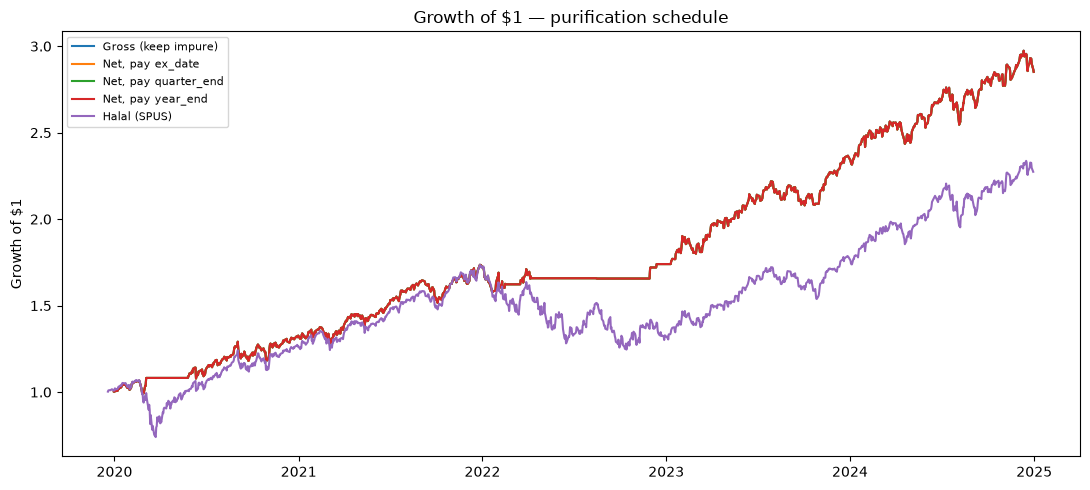

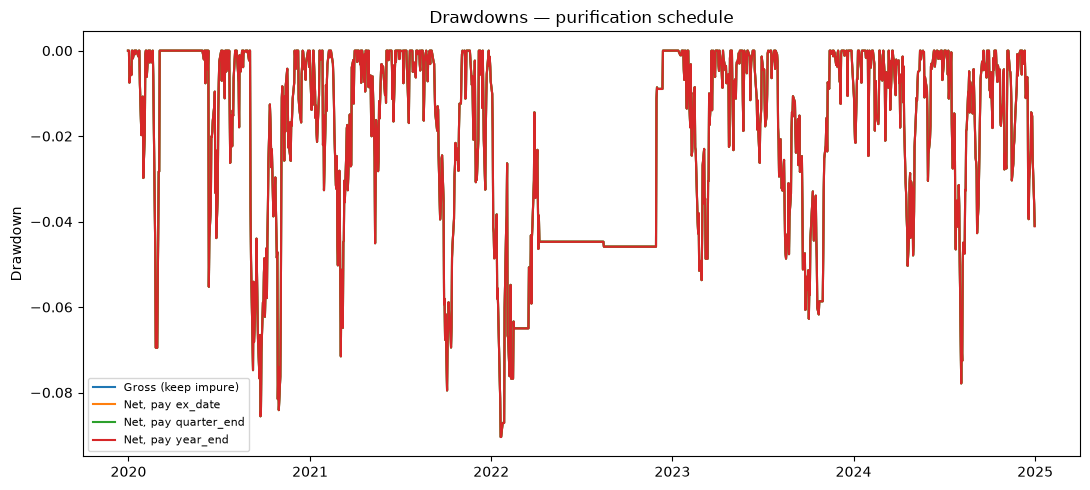

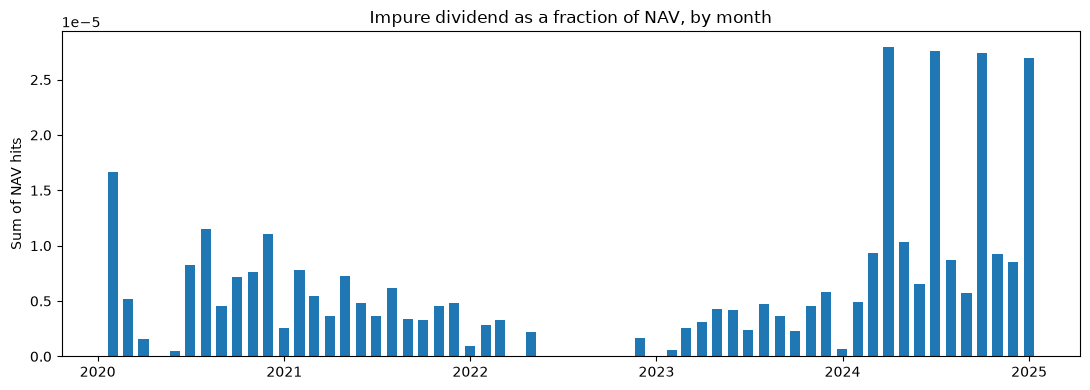

In [6]:
plot_keys = [
    "Gross (keep impure)",
    "Net, pay ex_date",
    "Net, pay quarter_end",
    "Net, pay year_end",
    "Halal (SPUS)",
]
plot_keys = [k for k in plot_keys if k in series_map]

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    ax.plot(eq.index, eq.values, label=k)
ax.set_title("Growth of $1 — purification schedule")
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "equity-curves.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    if k == "Halal (SPUS)":
        continue
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, label=k)
ax.set_title("Drawdowns — purification schedule")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "drawdowns.png", dpi=140)
plt.show()

if not held_divs.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    ev = held_divs[held_divs["covered"]].copy()
    ev["ex_date"] = pd.to_datetime(ev["ex_date"])
    monthly = ev.set_index("ex_date").resample("ME")["nav_frac"].sum()
    ax.bar(monthly.index, monthly.values, width=20)
    ax.set_title("Impure dividend as a fraction of NAV, by month")
    ax.set_ylabel("Sum of NAV hits")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "nav-hits.png", dpi=140)
    plt.show()


## Step 6 — Pick

The investor path must not keep impure income. That means the **ex-date accrue** path is the live NAV.

The cheque calendar is ops: quarterly is enough if the extra return from riding until year-end is tiny. If riding is material, that is more reason not to delay the hit.

Missing ratios are a coverage number, not a 0% drag. Paper 12 can stress costs on this same net path.


In [7]:
net = table[table["schedule"].isin(SCHEDULES)].copy()
print(net[["book", "schedule", "full_cagr", "cagr_drag", "full_max_dd", "full_calmar"]].to_string(index=False))

ex = net.loc[net["schedule"] == "ex_date"].iloc[0]
ye = net.loc[net["schedule"] == "year_end"].iloc[0]
ride = float(ye["full_cagr"] - ex["full_cagr"]) if pd.notna(ye["full_cagr"]) and pd.notna(ex["full_cagr"]) else np.nan
print()
print(f"CAGR gap, year-end minus ex-date (impure cash riding the book): {ride:.4%}" if pd.notna(ride) else "no gap")

pick_nav = "ex_date"
pick_ops = "quarter_end" if pd.isna(ride) or abs(ride) < 0.002 else "ex_date"
print()
print(f"PICK investor path: purify_schedule={pick_nav!r} (accrue, do not keep impure cash)")
print(f"PICK cheque ops: {pick_ops} batch")
print()
print("Live rule:")
print("  FrozenRules().with_book(")
print("      sleeve_weights={'fcf_quality': 1.0},")
print("      name_cap=0.10,")
print("      throttle='spy_sma',")
print("      breach_exit='next_open',")
print(f"      purify_schedule={pick_nav!r},")
print("  )")


                book    schedule  full_cagr  cagr_drag  full_max_dd  full_calmar
    Net, pay ex_date     ex_date   0.233348   0.000087    -0.090378     2.581910
Net, pay quarter_end quarter_end   0.233351   0.000085    -0.090385     2.581748
   Net, pay year_end    year_end   0.233357   0.000079    -0.090419     2.580828

CAGR gap, year-end minus ex-date (impure cash riding the book): 0.0008%

PICK investor path: purify_schedule='ex_date' (accrue, do not keep impure cash)
PICK cheque ops: quarter_end batch

Live rule:
  FrozenRules().with_book(
      sleeve_weights={'fcf_quality': 1.0},
      name_cap=0.10,
      throttle='spy_sma',
      breach_exit='next_open',
      purify_schedule='ex_date',
  )


## How to read the pick

- **Gross** is papers 07–10. It is useful as a control. It is not what a Halal unit-holder should be quoted.
- **Ex-date** is the clean rule: when the stock pays, the impure slice is a payable, not equity.
- **Quarter / year** only matter if you leave that payable invested. The extra return is the market's, on money you already owed as charity.
- Coverage below 100% means some dividends had no interest-income tag. We fill from the last filing when we can. The rest is a gap for the Sharia board, not a silent zero.

**Not in this paper:** trading costs at scale (12), zakat on wealth (different from dividend purification), or the cash vehicle used while the SMA is off.
